In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
deliveries = pd.read_csv("/content/deliveries.csv")

print("Dataset shape:", deliveries.shape)
print("\nDataset columns:")
print(deliveries.columns.tolist())

Dataset shape: (179078, 21)

Dataset columns:
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs', 'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed', 'dismissal_kind', 'fielder']


In [4]:
numeric_data = deliveries.select_dtypes(include="number")

print("Numeric columns:")
print(numeric_data.columns.tolist())

Numeric columns:
['match_id', 'inning', 'over', 'ball', 'is_super_over', 'wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs', 'batsman_runs', 'extra_runs', 'total_runs']


In [5]:
correlation_data = deliveries[
    [
        "inning",
        "over",
        "ball",
        "wide_runs",
        "bye_runs",
        "legbye_runs",
        "noball_runs",
        "penalty_runs",
        "batsman_runs",
        "extra_runs",
        "total_runs"
    ]
]

print("Selected features:")
print(correlation_data.columns.tolist())

Selected features:
['inning', 'over', 'ball', 'wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs', 'batsman_runs', 'extra_runs', 'total_runs']


In [6]:
correlation_matrix = correlation_data.corr(method="pearson")

print("Pearson Correlation Matrix:")
print(correlation_matrix.round(2))

Pearson Correlation Matrix:
              inning  over  ball  wide_runs  bye_runs  legbye_runs  \
inning          1.00 -0.05 -0.00       0.00     -0.00        -0.00   
over           -0.05  1.00 -0.01      -0.01      0.01        -0.00   
ball           -0.00 -0.01  1.00      -0.00      0.01        -0.00   
wide_runs       0.00 -0.01 -0.00       1.00     -0.01        -0.02   
bye_runs       -0.00  0.01  0.01      -0.01      1.00        -0.00   
legbye_runs    -0.00 -0.00 -0.00      -0.02     -0.00         1.00   
noball_runs    -0.00  0.02  0.00      -0.01     -0.00        -0.01   
penalty_runs    0.00 -0.00  0.00       0.01     -0.00        -0.00   
batsman_runs   -0.01  0.09  0.01      -0.09     -0.02        -0.07   
extra_runs     -0.00 -0.00 -0.00       0.72      0.33         0.55   
total_runs     -0.01  0.09  0.01       0.06      0.05         0.05   

              noball_runs  penalty_runs  batsman_runs  extra_runs  total_runs  
inning              -0.00          0.00         -0.

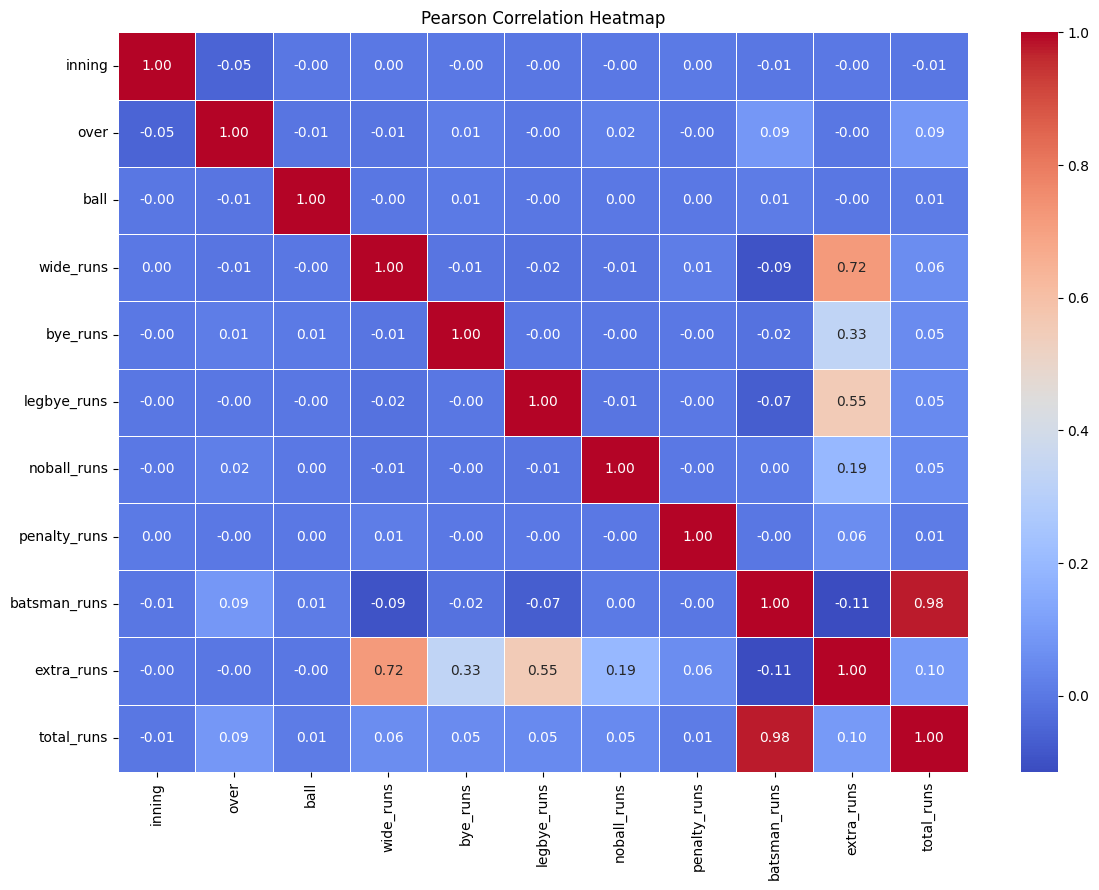

Heatmap saved as correlation_heatmap.png


In [7]:
plt.figure(figsize=(12, 9))

mask = correlation_matrix.where(
    ~correlation_matrix.isna()
).where(
    ~correlation_matrix.columns.to_series().duplicated()
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    mask=correlation_matrix.isnull(),
    linewidths=0.5
)

plt.title("Pearson Correlation Heatmap")
plt.tight_layout()

plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()

print("Heatmap saved as correlation_heatmap.png")

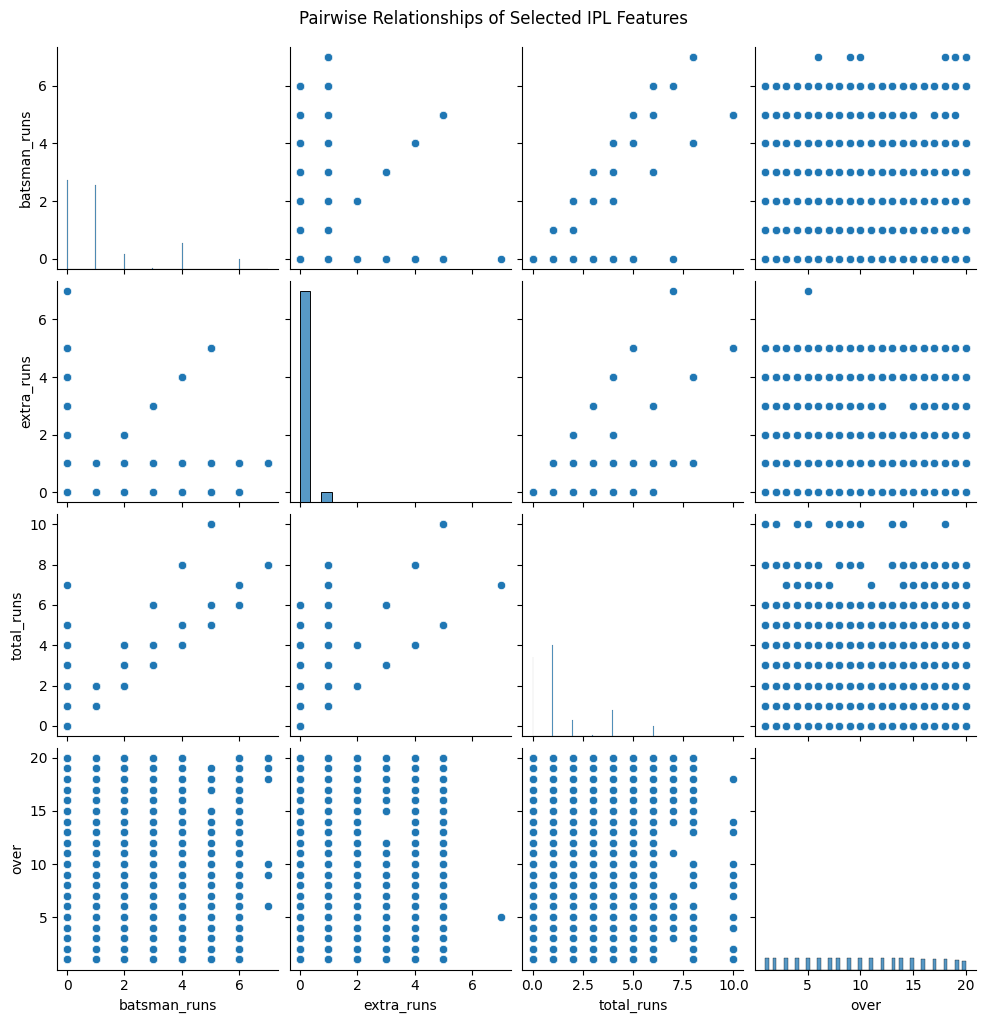

Pairwise plot saved as pairwise_relationships.png


In [8]:
pairwise_data = deliveries[
    ["batsman_runs", "extra_runs", "total_runs", "over"]
]

sns.pairplot(
    pairwise_data,
    diag_kind="hist"
)

plt.suptitle("Pairwise Relationships of Selected IPL Features", y=1.02)

plt.savefig("pairwise_relationships.png", dpi=300, bbox_inches="tight")
plt.show()

print("Pairwise plot saved as pairwise_relationships.png")

In [9]:
corr_pairs = correlation_matrix.where(
    ~pd.DataFrame(
        [[i >= j for j in range(len(correlation_matrix.columns))]
         for i in range(len(correlation_matrix.columns))],
        index=correlation_matrix.index,
        columns=correlation_matrix.columns
    )
).stack().sort_values()

print("Strongest negative relationships:")
print(corr_pairs.head(5))

print("\nStrongest positive relationships:")
print(corr_pairs.tail(5))

Strongest negative relationships:
batsman_runs  extra_runs     -0.114806
wide_runs     batsman_runs   -0.094579
legbye_runs   batsman_runs   -0.070106
inning        over           -0.050076
bye_runs      batsman_runs   -0.018936
dtype: float64

Strongest positive relationships:
noball_runs   extra_runs    0.194899
bye_runs      extra_runs    0.332352
legbye_runs   extra_runs    0.554458
wide_runs     extra_runs    0.720916
batsman_runs  total_runs    0.977278
dtype: float64


## Interpretation

The Pearson correlation analysis shows that batsman runs and total runs have the strongest positive relationship, with a correlation of 0.98. Wide runs and extra runs also show a strong positive relationship of 0.72, while legbye runs and extra runs have a moderate positive relationship of 0.55. The strongest negative relationship is between batsman runs and extra runs, with a correlation of -0.11, which indicates a weak negative relationship. The heatmap and pairwise plots provide a visual representation of these relationships among the selected IPL delivery features.

## Project Summary

This project analyzed relationships among numeric features in IPL delivery data using Pearson correlation and pairwise visualization techniques.

### Visualizations Created

- Pearson correlation heatmap with annotated values
- Pairwise relationship plot for selected features

### Key Findings

- Strongest positive relationship: batsman_runs and total_runs (0.98)
- Wide runs and extra runs: 0.72
- Legbye runs and extra runs: 0.55
- Strongest negative relationship: batsman_runs and extra_runs (-0.11)

### Tools Used

- Python
- Pandas
- Matplotlib
- Seaborn
- Google Colab
- GitHub